In [4]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
location_A_scores = np.random.normal(loc=75, scale=10, size=100)  # mean=75, std=10
location_B_scores = np.random.normal(loc=78, scale=10, size=100)  # mean=78, std=10

# Create DataFrame
df = pd.DataFrame({
    'Score': np.concatenate([location_A_scores, location_B_scores]),
    'Location': ['A']*100 + ['B']*100
})
print(df)

         Score Location
0    79.967142        A
1    73.617357        A
2    81.476885        A
3    90.230299        A
4    72.658466        A
..         ...      ...
195  81.853174        B
196  69.161426        B
197  79.537251        B
198  78.582087        B
199  66.570297        B

[200 rows x 2 columns]


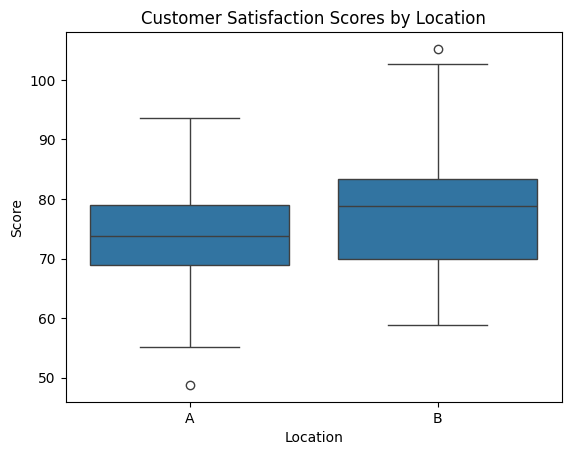

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='Location', y='Score', data=df)
plt.title('Customer Satisfaction Scores by Location')
plt.show()

In [5]:
from scipy.stats import shapiro

stat_A, p_A = shapiro(location_A_scores)
stat_B, p_B = shapiro(location_B_scores)

print(f"Location A normality p-value: {p_A}")
print(f"Location B normality p-value: {p_B}")

Location A normality p-value: 0.6551676754214818
Location B normality p-value: 0.08525602813445946


In [6]:
from scipy.stats import levene

stat_levene, p_levene = levene(location_A_scores, location_B_scores)
print(f"Levene's test p-value: {p_levene}")

Levene's test p-value: 0.6715053895987048


In [7]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(location_A_scores, location_B_scores, equal_var=(p_levene > 0.05))
print(f"T-test p-value: {p_value}")

mean_A = np.mean(location_A_scores)
mean_B = np.mean(location_B_scores)
overall_mean = np.mean(df['Score'])
accuracy_A = 100 - abs(mean_A - overall_mean) / overall_mean * 100
accuracy_B = 100 - abs(mean_B - overall_mean) / overall_mean * 100

print(f"Location A accuracy: {accuracy_A:.2f}%")
print(f"Location B accuracy: {accuracy_B:.2f}%")

T-test p-value: 0.0014208821931448936
Location A accuracy: 97.20%
Location B accuracy: 97.20%
